In [1]:
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import optuna

from plotly.subplots import make_subplots
from matplotlib import pyplot as plt
from mlforecast import MLForecast
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, AutoARIMA, AutoETS
from typing import Callable, List, Type

# Helper functions

In [2]:
def add_horizon(cv_df: pd.DataFrame) -> pd.DataFrame:
    cv_df = cv_df.copy()
    cv_df['horizon'] = cv_df.groupby(['region', 'cutoff']).cumcount() + 1
    return cv_df

In [3]:
def eval_by_horizon(cv_df: pd.DataFrame, model_cols: List[str]) -> pd.DataFrame:
    rows = []
    
    for model in model_cols:
        row = {'model': model}
        
        for h in range(1, 5):
            subset = cv_df[cv_df['horizon'] == h]
            
            mae = mean_absolute_error(subset['price'], subset[model])
            mae_pct = (mae / subset['price'].mean()) * 100
            rmse = np.sqrt(mean_squared_error(subset['price'], subset[model]))
            
            row[f'H{h} MAE'] = round(mae, 0)
            row[f'H{h} MAE%'] = round(mae_pct, 2)
            row[f'H{h} RMSE'] = round(rmse, 0)
            
        rows.append(row)
    return pd.DataFrame(rows).set_index('model')

In [21]:
def display_eval_table(table: pd.DataFrame, caption: str) -> None:
    table = table.copy()
    
    for metric in ['MAE', 'MAE%', 'RMSE']:
        cols = [c for c in table.columns if c.endswith(metric)]
        table[f'Avg {metric}'] = table[cols].mean(axis=1)
    
    mae_pct_cols = [c for c in table.columns if 'MAE%' in c]
    rmse_cols = [c for c in table.columns if 'RMSE' in c and 'MAE' not in c]

    display(table.style
        .format({
            col: '{:.2f}%' if 'MAE%' in col else '{:.0f}'
            for col in table.columns
        })
        .background_gradient(cmap='Blues', axis=None, subset=mae_pct_cols)
        .background_gradient(cmap='Purples', axis=None, subset=rmse_cols)
        .set_caption(caption)
    )

In [5]:
def show_graph(df: pd.DataFrame, forecasts: pd.DataFrame) -> None:
    regione = df["region"].unique()

    model_columns = [
        col for col in forecasts.columns
        if col not in ["region", "date"]
    ]

    colors = px.colors.qualitative.Plotly
    model_colors = {
        model: colors[i % len(colors)]
        for i, model in enumerate(model_columns)
    }

    fig = make_subplots(
        rows=len(regione),
        cols=1,
        shared_xaxes=False,
        vertical_spacing=0.02,
        subplot_titles=regione
    )

    trace_map = []

    for i, region in enumerate(regione, start=1):

        real = df[df["region"] == region]
        preds = forecasts[forecasts["region"] == region]

        # Actual
        fig.add_trace(
            go.Scatter(
                x=real["date"],
                y=real["price"],
                mode="lines",
                name="Actual",
                line=dict(color="black", width=4),
                showlegend=(i == 1)
            ),
            row=i,
            col=1
        )

        trace_map.append(("Actual", len(fig.data)-1))

        # Models
        for model in model_columns:
            if model in preds.columns:
                first_pred_date = preds["date"].iloc[0]
                last_actual = real[real["date"] < first_pred_date].iloc[-1]
                
                connector_x = [last_actual["date"]] + list(preds["date"])
                connector_y = [last_actual["price"]] + list(preds[model])
                
                fig.add_trace(
                    go.Scatter(
                        x=connector_x,
                        y=connector_y,
                        mode="lines",
                        name=model,
                        line=dict(color=model_colors[model]),
                        showlegend=(i == 1)
                    ),
                    row=i,
                    col=1
                )

                trace_map.append((model, len(fig.data)-1))

    # DROPDOWN MENU
    buttons = []

    for model in model_columns:
        visibility = []

        for name, idx in trace_map:
            if name == "Actual" or name == model:
                visibility.append(True)
            else:
                visibility.append(False)

        buttons.append(
            dict(
                label=model,
                method="update",
                args=[{"visible": visibility}]
            )
        )

    buttons.insert(
        0,
        dict(
            label="All models",
            method="update",
            args=[{"visible": [True] * len(trace_map)}]
        )
    )

    fig.update_layout(
        height=500 * len(regione),
        width=1100,
        legend=dict(
            orientation="v",
            x=1.02,
            xanchor="left",
            y=0.99,
            yanchor="top"
        ),
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                showactive=True,
                x=1.02,
                xanchor="left",
                y=1.0,
                yanchor="top"
            )
        ]
    )

    fig.show()

# Load Data

In [6]:
# Load dataset
df = pd.read_csv("data/dataset_ml.csv", sep=';', parse_dates=['date'], date_format='%d.%m.%Y')

dates_sorted = sorted(df['date'].unique())
holdout_dates = dates_sorted[-4:]           # 2024 Q1–Q4
cutoff_date = holdout_dates[0]              # 2024-03-31

df_train = df[df['date'] < cutoff_date].copy()    # training data
df_holdout = df[df['date'] >= cutoff_date].copy() # holdout data

print(f"Training set ends at:  {df_train['date'].max().date()}")
print(f"Holdout set starts at: {df_holdout['date'].min().date()}")

df.head(10)

Training set ends at:  2023-12-31
Holdout set starts at: 2024-03-31


,region,date,price
0,praha,2019-03-31,73818
1,praha,2019-06-30,75162
2,praha,2019-09-30,77202
3,praha,2019-12-31,79382
4,stredocesky,2019-03-31,28777
5,stredocesky,2019-06-30,31328
6,stredocesky,2019-09-30,31846
7,stredocesky,2019-12-31,32882
8,jihocesky,2019-03-31,26028
9,jihocesky,2019-06-30,26896


In [7]:
# Prague only
only_prague = df_train[df_train["region"] == "praha"]
one_length = len(only_prague)
print(one_length)
print(only_prague)

20
    region       date   price
0    praha 2019-03-31   73818
1    praha 2019-06-30   75162
2    praha 2019-09-30   77202
3    praha 2019-12-31   79382
56   praha 2020-03-31   82409
57   praha 2020-06-30   84096
58   praha 2020-09-30   88315
59   praha 2020-12-31   88315
112  praha 2021-03-31   93413
113  praha 2021-06-30   96950
114  praha 2021-09-30  103196
115  praha 2021-12-31  109350
168  praha 2022-03-31  110995
169  praha 2022-06-30  114746
170  praha 2022-09-30  114792
171  praha 2022-12-31  110171
224  praha 2023-03-31  103549
225  praha 2023-06-30  103992
226  praha 2023-09-30  103859
227  praha 2023-12-31  103372


In [8]:
fig = px.line(
    df_train,
    x="date",
    y="price",
    color="region",
    title="Historical apartment prices in CR",
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

fig.update_yaxes(range=[df["price"].min(), df["price"].max()])

fig.update_layout(
    autosize=True,
    height=500,
    xaxis_title="Price [m2]",
    yaxis_title="Date",
    legend_title="Region"
)

fig.show()

In [9]:
all_prices = df_train.pivot(index="date", columns="region", values="price").reset_index()
all_prices.describe()

region,date,jihocesky,jihomoravsky,karlovarsky,kralovehradecky,liberecky,moravskoslezsky,olomoucky,pardubicky,plzensky,praha,stredocesky,ustecky,vysocina,zlinsky
count,20,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2021-08-15 01:12:00,39707.150000,55455.600000,28958.00000,39141.000000,38689.800000,33277.000000,38839.900000,41436.950000,41583.100000,95854.200000,44749.450000,28782.750000,39296.000000,38291.550000
min,2019-03-31 00:00:00,26028.000000,39865.000000,20701.00000,27075.000000,24875.000000,22170.000000,27515.000000,28214.000000,30769.000000,73818.000000,28777.000000,18357.000000,26948.000000,27871.000000
25%,2020-06-07 06:00:00,32658.500000,46353.500000,23192.00000,31684.750000,31137.000000,26916.500000,31705.750000,34977.000000,33722.250000,83674.250000,37166.250000,23037.500000,31446.500000,30220.750000
50%,2021-08-15 00:00:00,41073.500000,57148.000000,29828.50000,41026.000000,39067.000000,35189.000000,39138.000000,42864.000000,42313.000000,100073.000000,46307.000000,30584.000000,39570.500000,39016.500000
75%,2022-10-23 00:00:00,46287.000000,65222.000000,33729.75000,46505.000000,46103.000000,38909.000000,46039.250000,49818.750000,48177.250000,105331.500000,52822.000000,34273.000000,46639.750000,45472.500000
max,2023-12-31 00:00:00,52378.000000,69560.000000,37072.00000,48994.000000,50588.000000,43130.000000,49722.000000,52349.000000,53267.000000,114792.000000,57688.000000,37495.000000,50247.000000,49553.000000
std,NaN,8825.231545,10839.622728,6012.02003,8205.422135,8580.439343,7451.629317,8202.941019,8746.516085,8267.243198,13773.904868,9723.451334,6581.286851,8257.290361,8036.761874


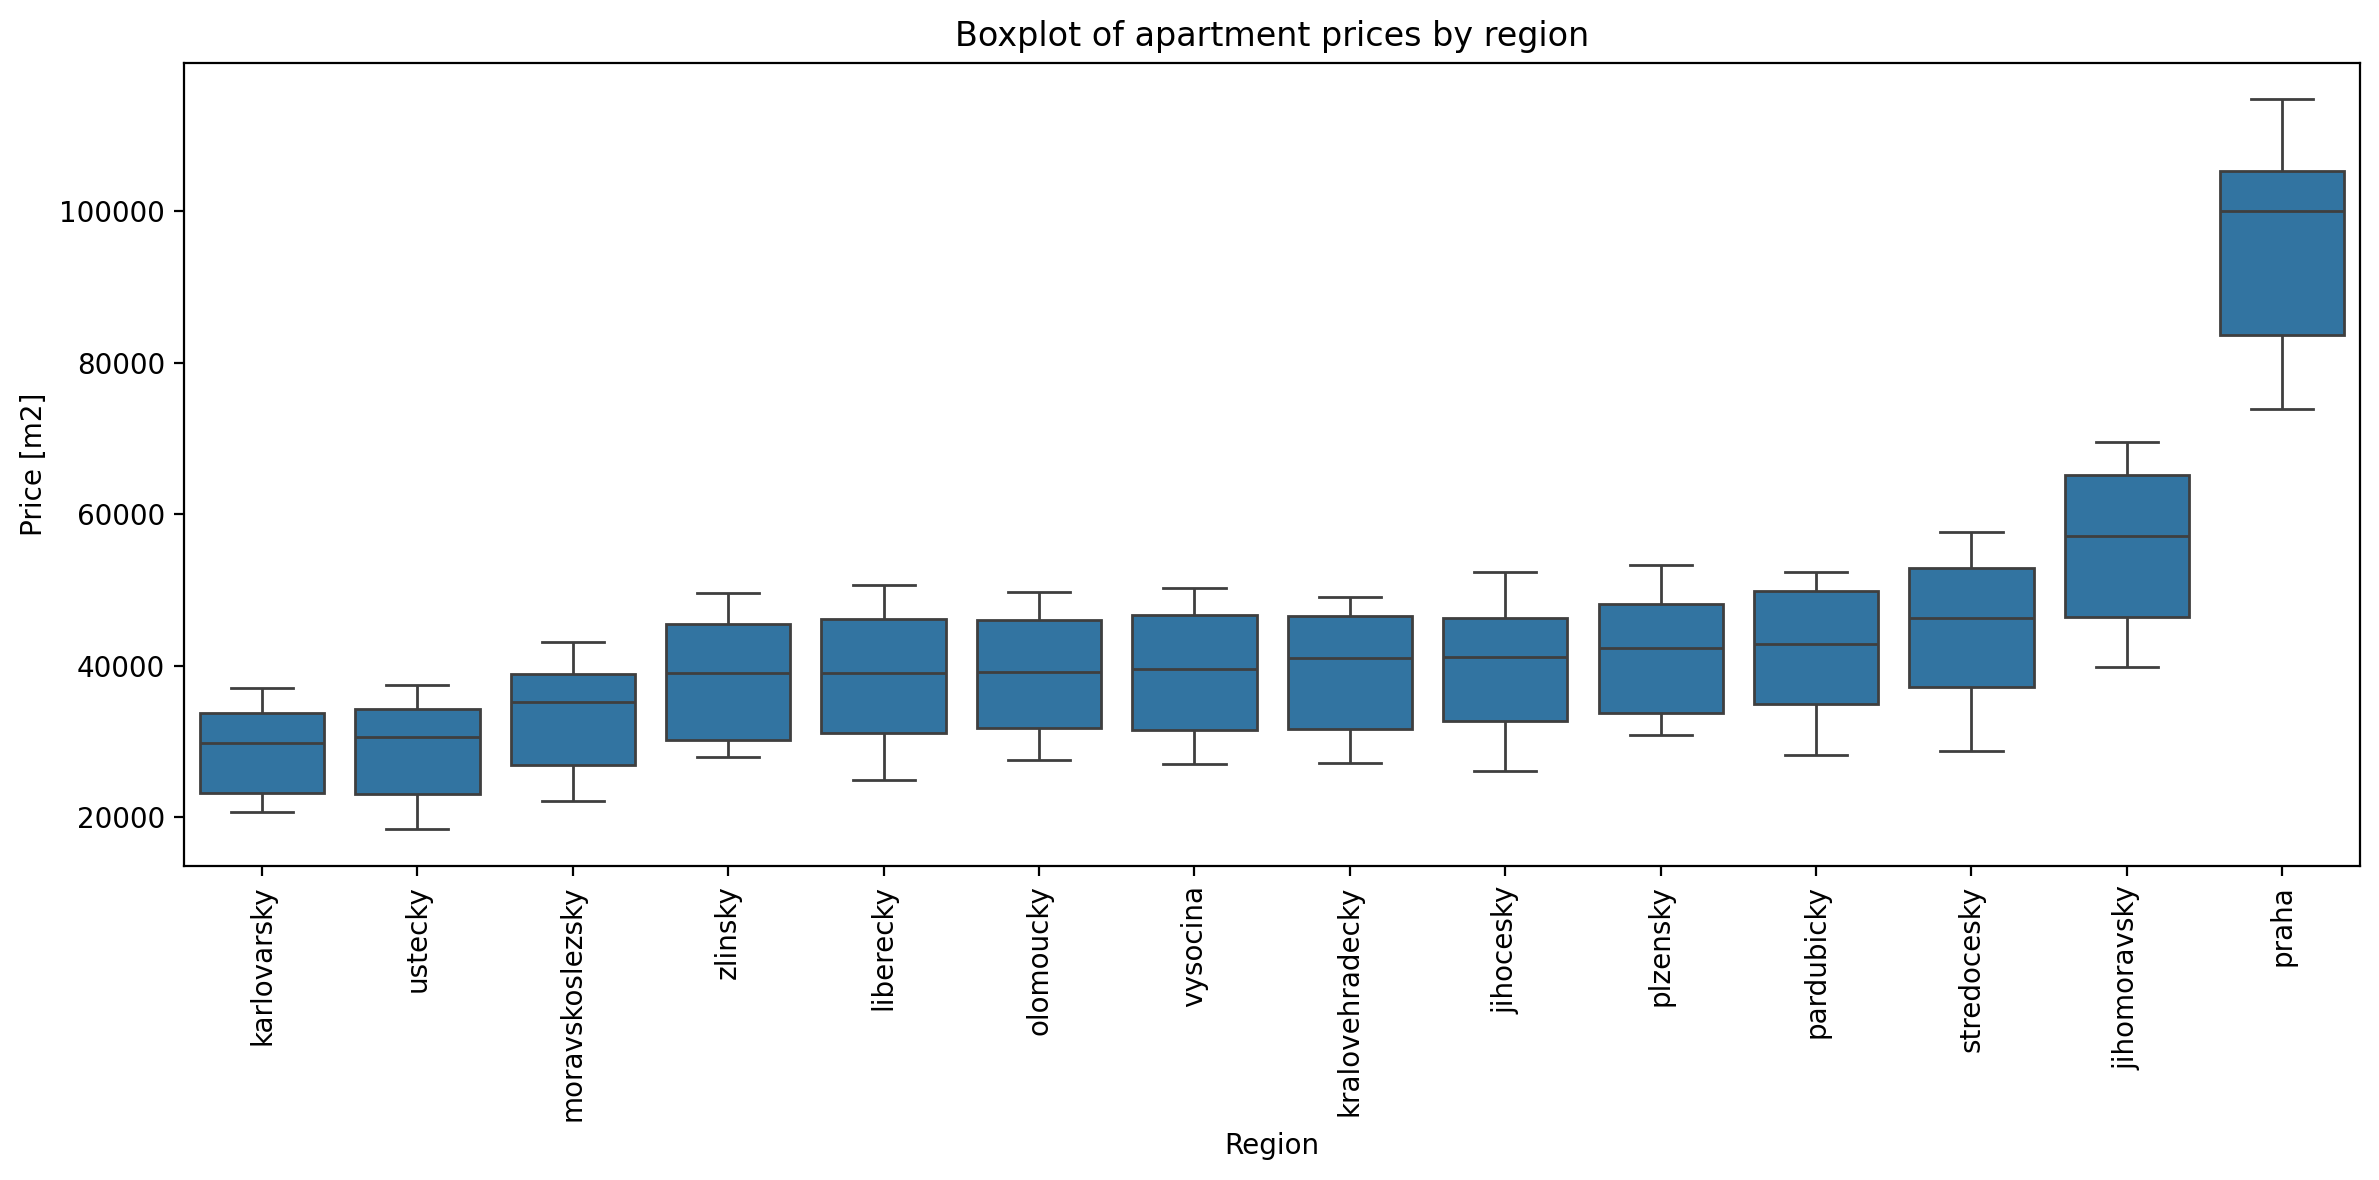

In [10]:
order = df_train.groupby("region")["price"].median().sort_values().index

plt.figure(figsize=(12, 6), dpi=200)
sns.boxplot(data=df_train, x="region", y="price", order=order)
plt.xticks(rotation=90)
plt.xlabel("Region")
plt.ylabel("Price [m2]")
plt.title("Boxplot of apartment prices by region")
plt.tight_layout()
plt.show()

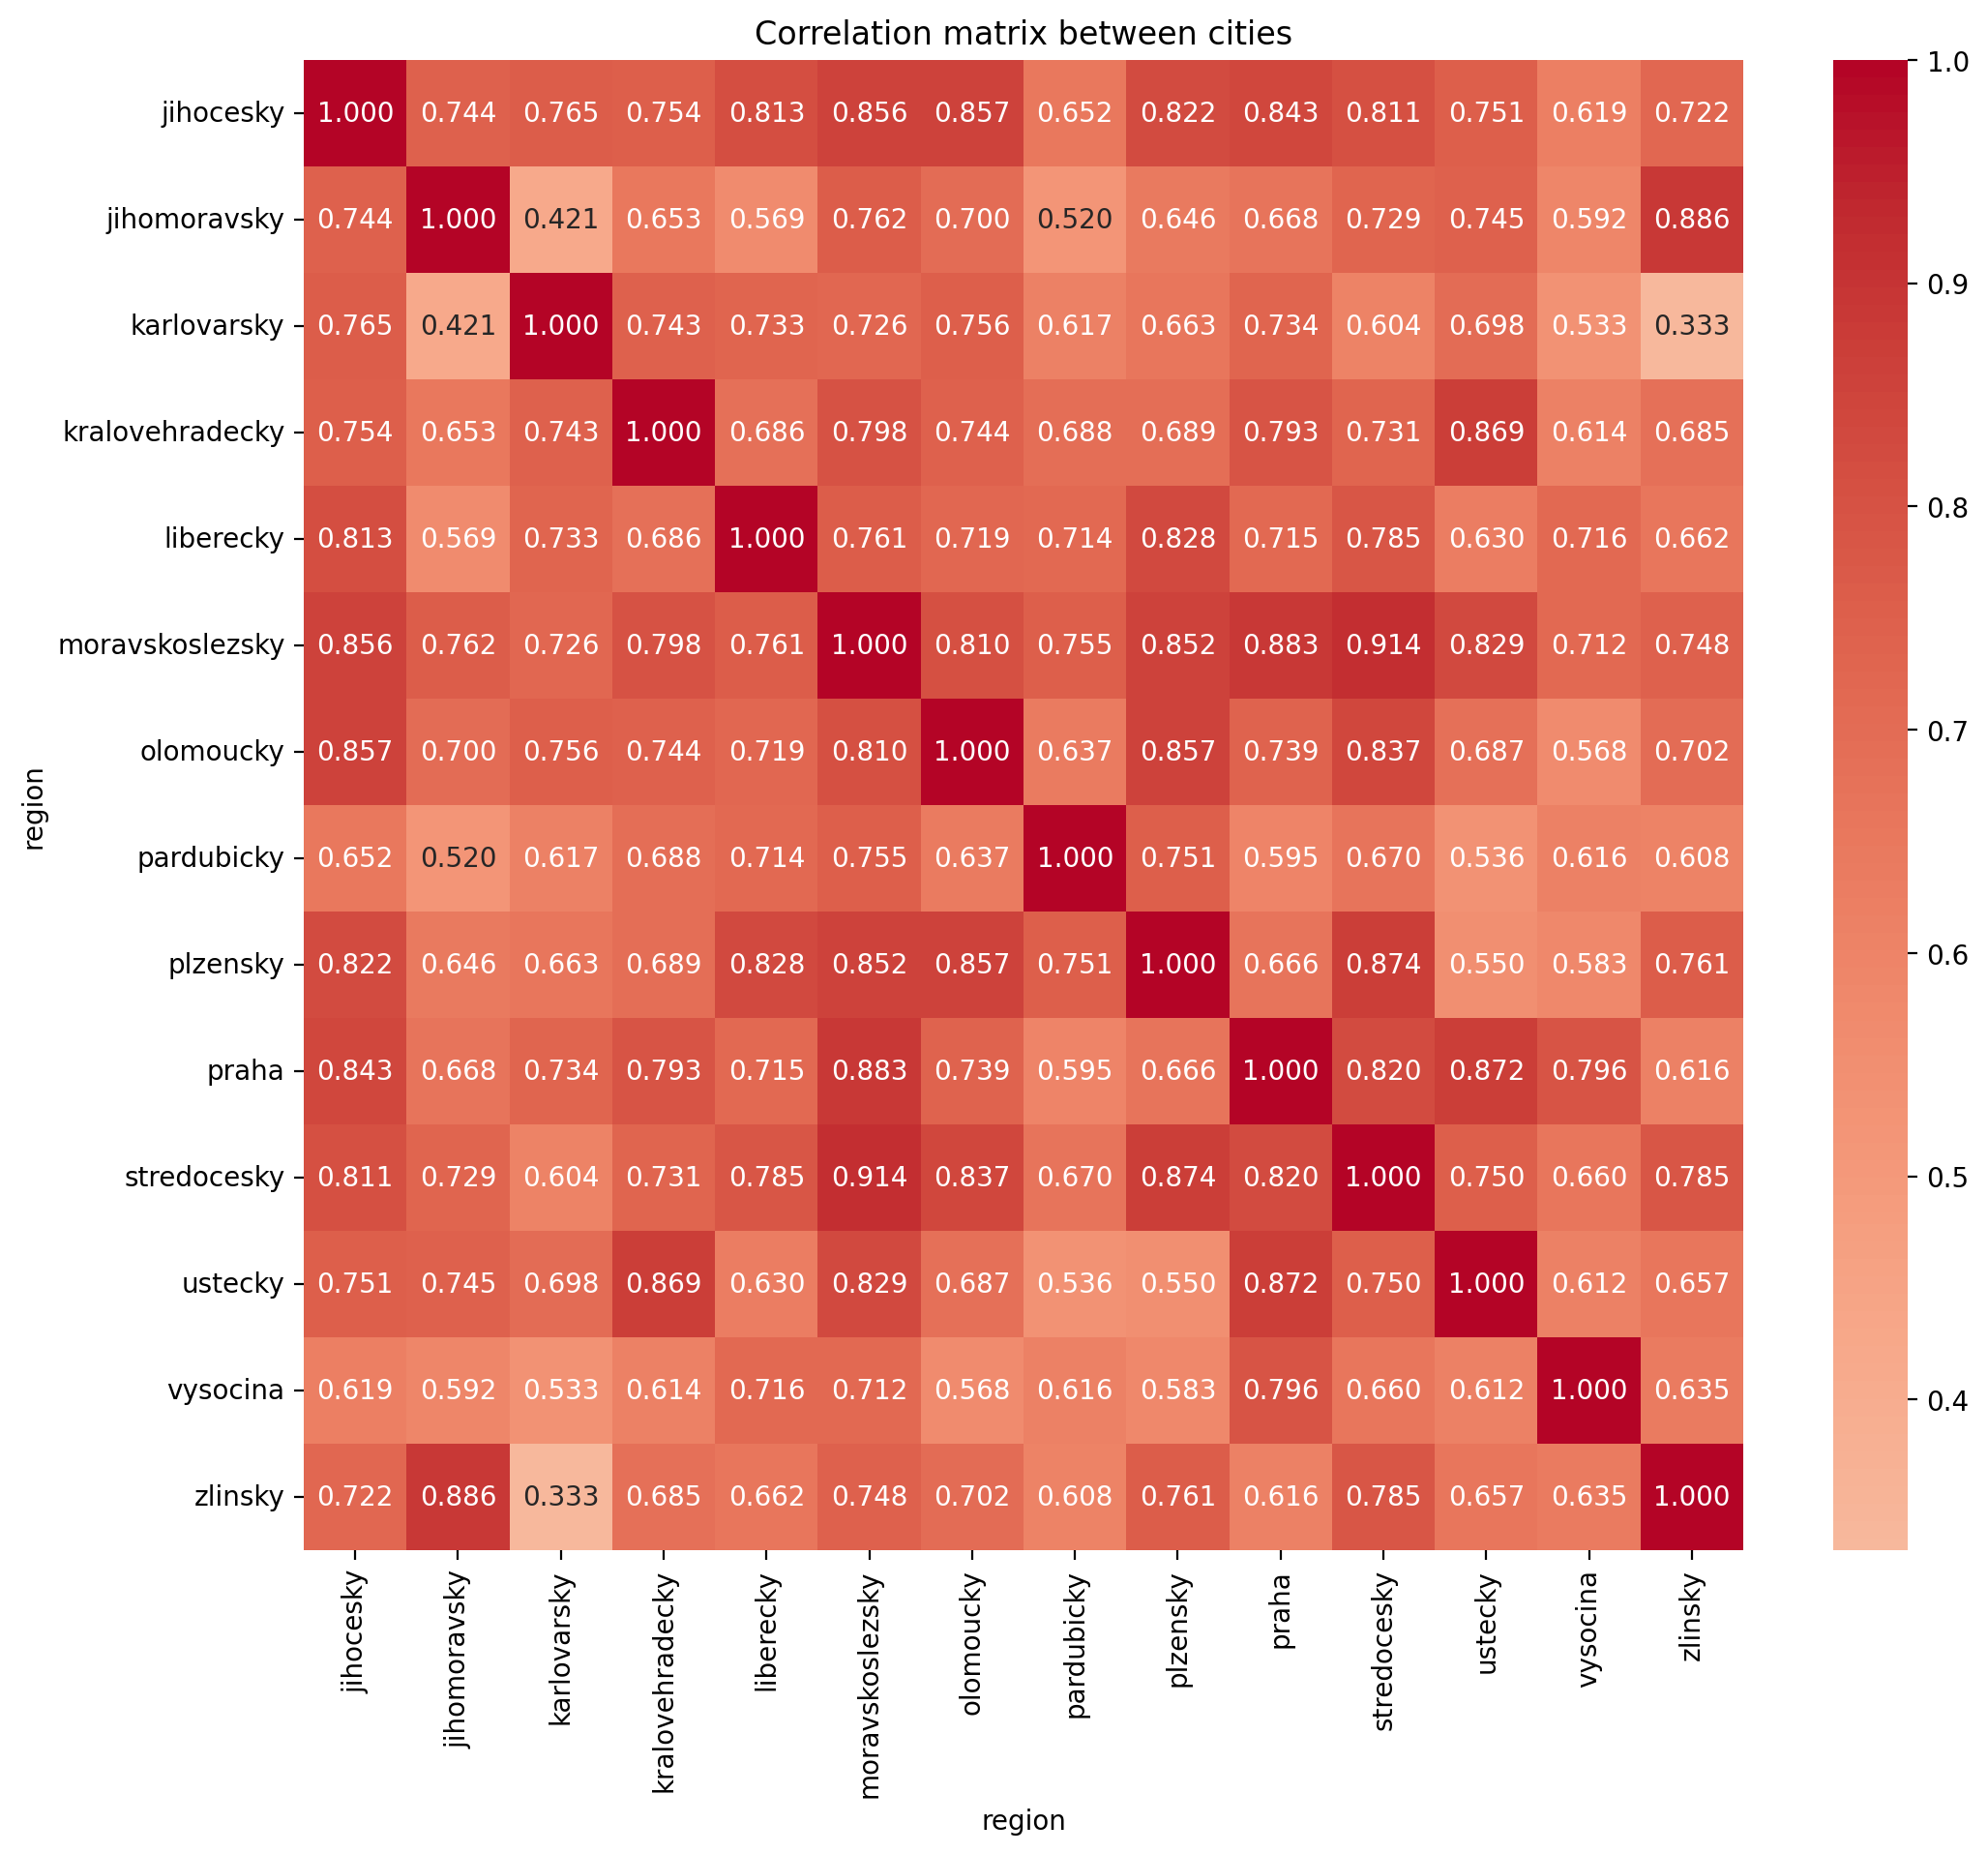

In [11]:
all_prices_diff = all_prices.set_index("date").diff().dropna()
corr_matrix = all_prices_diff.corr()

plt.figure(figsize=(12, 10), dpi=200)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation matrix between cities")
plt.show()

# Model Evaluation

## Hyperparameters

In [12]:
lags = [1, 2, 3, 4]
h = 4
step_size = 1

min_train_size = max(lags)
max_num_windows = (one_length - min_train_size - h) // step_size
print(max_num_windows)

12


## Random Forest Regressor & XGBoost Hyperparameter Tuning

In [13]:
def tune_model(model_class: Type, param_func: Callable[[optuna.Trial], dict], n_trials: int=20) -> dict:
    model_name = model_class.__name__
    print(f"Initializing tuning for: {model_name}...")

    def objective(trial):
        params = param_func(trial)
        
        model = model_class(**params)
        
        mlf_tune = MLForecast(
            models=[model],
            freq='QE',
            lags=lags
        )
        
        cv_results = mlf_tune.cross_validation(
            df=df_train, 
            h=h, 
            step_size=step_size,
            n_windows=max_num_windows,
            id_col='region',
            time_col='date', 
            target_col='price',
        )
        
        error = mean_absolute_error(cv_results['price'], cv_results[model_name])
        return error

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"Tuning {model_name} completed. Best MAE: {study.best_value:.2f}")
    return study.best_params

In [14]:
def xgb_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 0,
        'n_jobs': -1
    }

def rf_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'random_state': 0,
        'n_jobs': -1
    }

best_params_xgb = tune_model(XGBRegressor, xgb_params, 20)
best_params_rf = tune_model(RandomForestRegressor, rf_params, 20)

[I 2026-03-20 21:28:48,787] A new study created in memory with name: no-name-bc69050d-0915-45e6-a15f-b74c392f9e9e


Initializing tuning for: XGBRegressor...


[I 2026-03-20 21:28:49,758] Trial 0 finished with value: 5310.4638671875 and parameters: {'n_estimators': 159, 'max_depth': 2, 'learning_rate': 0.026828160196348334, 'subsample': 0.8268091840923601, 'colsample_bytree': 0.7139141351357271}. Best is trial 0 with value: 5310.4638671875.
[I 2026-03-20 21:28:50,670] Trial 1 finished with value: 4889.4951171875 and parameters: {'n_estimators': 173, 'max_depth': 2, 'learning_rate': 0.06311093872834679, 'subsample': 0.8697182964638692, 'colsample_bytree': 0.8377420277251244}. Best is trial 1 with value: 4889.4951171875.
[I 2026-03-20 21:28:51,323] Trial 2 finished with value: 6440.3251953125 and parameters: {'n_estimators': 54, 'max_depth': 5, 'learning_rate': 0.03318744118319791, 'subsample': 0.958220785027194, 'colsample_bytree': 0.6861277796415077}. Best is trial 1 with value: 4889.4951171875.
[I 2026-03-20 21:28:52,032] Trial 3 finished with value: 5425.0849609375 and parameters: {'n_estimators': 114, 'max_depth': 2, 'learning_rate': 0.032

Tuning XGBRegressor completed. Best MAE: 4839.07
Initializing tuning for: RandomForestRegressor...


[I 2026-03-20 21:29:14,879] Trial 0 finished with value: 5293.814650121385 and parameters: {'n_estimators': 209, 'max_depth': 6, 'min_samples_split': 3}. Best is trial 0 with value: 5293.814650121385.
[I 2026-03-20 21:29:17,848] Trial 1 finished with value: 5655.045590367756 and parameters: {'n_estimators': 89, 'max_depth': 3, 'min_samples_split': 8}. Best is trial 0 with value: 5293.814650121385.
[I 2026-03-20 21:29:22,589] Trial 2 finished with value: 5820.908146359468 and parameters: {'n_estimators': 183, 'max_depth': 4, 'min_samples_split': 7}. Best is trial 0 with value: 5293.814650121385.
[I 2026-03-20 21:29:26,646] Trial 3 finished with value: 6591.339179141849 and parameters: {'n_estimators': 164, 'max_depth': 7, 'min_samples_split': 10}. Best is trial 0 with value: 5293.814650121385.
[I 2026-03-20 21:29:31,981] Trial 4 finished with value: 5684.331016833114 and parameters: {'n_estimators': 216, 'max_depth': 3, 'min_samples_split': 8}. Best is trial 0 with value: 5293.814650121

Tuning RandomForestRegressor completed. Best MAE: 5184.61


## Training

In [24]:
best_xgb = XGBRegressor(**best_params_xgb, random_state=0)
best_rf = RandomForestRegressor(**best_params_rf, random_state=0)

mlf = MLForecast(
    models=[
        LinearRegression(),
        best_xgb,
        best_rf
    ],
    freq='QE',
    lags=lags,
)

sf = StatsForecast(
    models=[
        Naive(), 
        HistoricAverage(), 
        WindowAverage(window_size=max(lags)),
        AutoARIMA(season_length=max(lags)),
        AutoETS(season_length=max(lags))
    ],
    freq='QE',
    n_jobs=-1,
)

h_cv = 4
max_num_windows_cv = (one_length - min_train_size - 2 - h_cv) // step_size
print(f"max_num_windows for h=4: {max_num_windows_cv}")

cv_results_ml = add_horizon(mlf.cross_validation(
    df=df_train, 
    h=h_cv, 
    step_size=step_size, 
    n_windows=max_num_windows_cv,
    id_col='region', 
    time_col='date', 
    target_col='price',
))

cv_results_stat = add_horizon(sf.cross_validation(
    df=df_train, 
    h=h_cv, 
    step_size=step_size, 
    n_windows=max_num_windows_cv,
    id_col='region', 
    time_col='date', 
    target_col='price',
))

max_num_windows for h=4: 10


## Results Analysis

In [25]:
table_ml = eval_by_horizon(cv_results_ml, [str(m) for m in mlf.models])
table_stat = eval_by_horizon(cv_results_stat, [m.alias for m in sf.models])

display_eval_table(pd.concat([table_ml, table_stat]), "MAE and RMSE by forecast horizon (H1–H4)")

,H1 MAE,H1 MAE%,H1 RMSE,H2 MAE,H2 MAE%,H2 RMSE,H3 MAE,H3 MAE%,H3 RMSE,H4 MAE,H4 MAE%,H4 RMSE,Avg MAE,Avg MAE%,Avg RMSE
model,,,,,,,,,,,,,,,
LinearRegression,2187,4.56%,2657,4082,8.29%,5050,5981,11.92%,7313,8161,16.03%,9774,5103,10.20%,6198
XGBRegressor,2285,4.76%,2766,4414,8.96%,5071,6379,12.71%,7258,8035,15.78%,9192,5278,10.55%,6072
RandomForestRegressor,2601,5.42%,3174,4717,9.58%,5710,6632,13.21%,8023,8576,16.85%,10153,5632,11.27%,6765
Naive,2327,4.85%,2735,4391,8.92%,4905,5920,11.80%,6766,7018,13.79%,8256,4914,9.84%,5666
HistoricAverage,10836,22.59%,11757,12116,24.60%,12871,13064,26.03%,13813,13777,27.06%,14582,12448,25.07%,13256
WindowAverage,4861,10.13%,5515,6573,13.35%,7440,7723,15.39%,8994,8454,16.61%,10211,6903,13.87%,8040
AutoARIMA,2356,4.91%,2876,4319,8.77%,5116,6327,12.61%,7304,8114,15.94%,9397,5279,10.56%,6173
AutoETS,2551,5.32%,3008,4849,9.85%,5424,7060,14.07%,7692,8913,17.51%,9708,5843,11.69%,6458


## Graphical Visualization

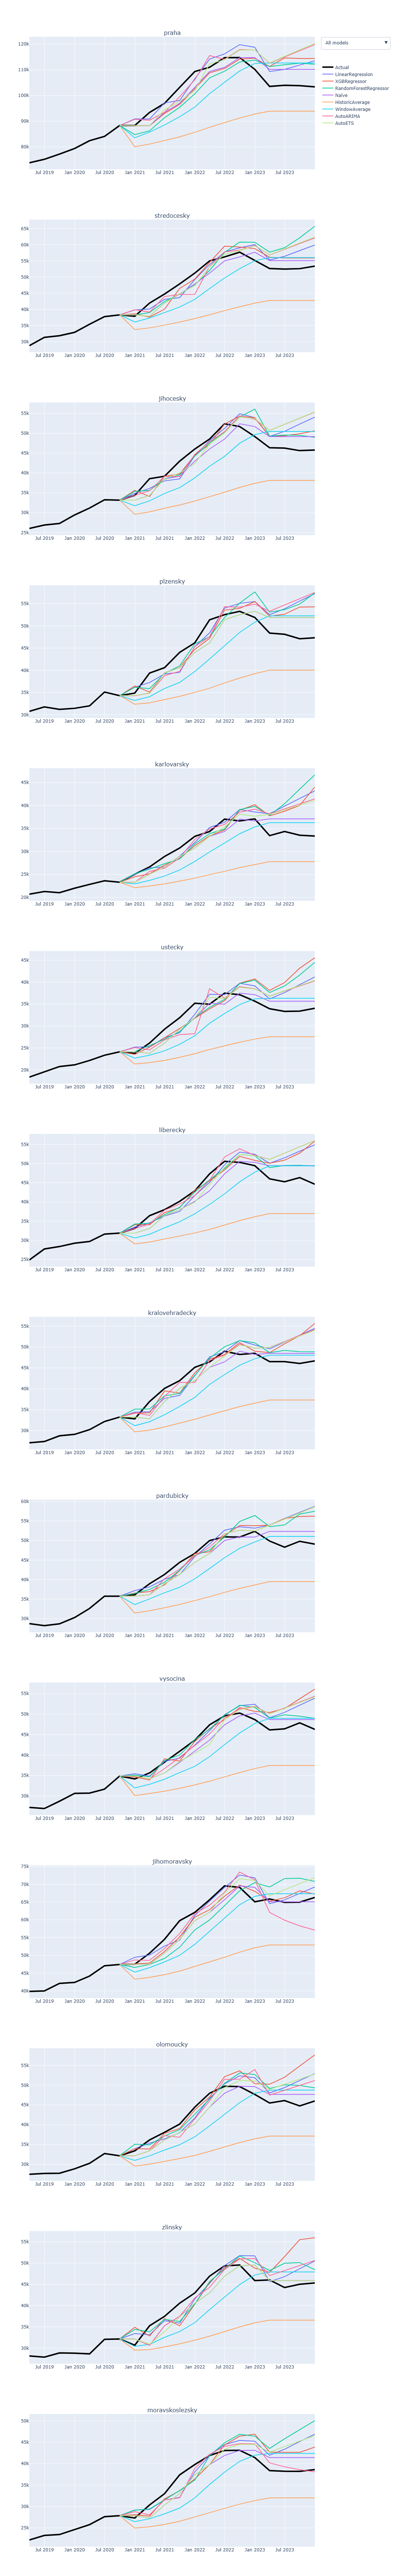

In [26]:
ml_forecasts = (cv_results_ml
    .sort_values("cutoff")
    .groupby(["region", "date"])
    .last()
    .reset_index()
    .drop(columns=["price", "cutoff", "horizon"]))

stat_forecasts = (cv_results_stat
    .sort_values("cutoff")
    .groupby(["region", "date"])
    .last()
    .reset_index()
    .drop(columns=["price", "cutoff", "horizon"]))

combined_forecasts = pd.merge(
    ml_forecasts, 
    stat_forecasts, 
    on=["region", "date"], 
    how="inner"
)

show_graph(df_train, combined_forecasts)

# Prediction

In [27]:
mlf.fit(
    df=df_train,
    id_col='region',
    time_col='date',
    target_col='price',
    static_features=[]
)

sf.fit(
    df=df_train,
    id_col='region',
    time_col='date',
    target_col='price'
)

h = 4

predictions_sf = sf.predict(h=h)
predictions_ml = mlf.predict(h=h)

predictions_arima = predictions_sf[['region', 'date', 'AutoARIMA', 'AutoETS']]

combined_predictions = pd.merge(
    predictions_ml, 
    predictions_arima, 
    on=['region', 'date'], 
    how='inner'
)

## Graph Vizualization

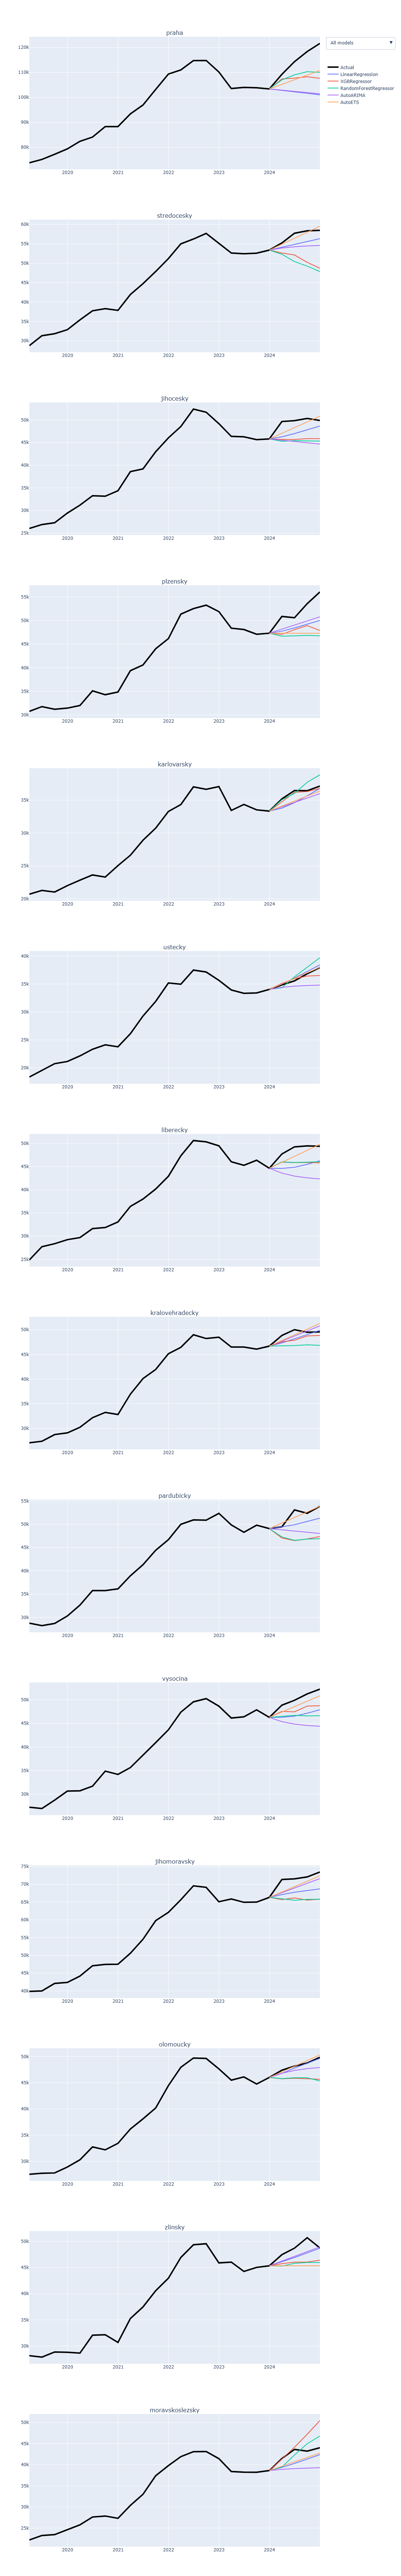

In [28]:
show_graph(df, combined_predictions)

## Prediction Evaluation

In [29]:
combined_predictions = combined_predictions.drop(
    columns=[c for c in combined_predictions.columns if 'Naive' in c],
    errors='ignore'
)

# Naive
naive_pred = (df_train.groupby('region')['price']
              .last()
              .reset_index()
              .rename(columns={'price': 'Naive'}))
future_dates = sorted(df['date'].unique())[-4:]
naive_pred = pd.concat([
    naive_pred.assign(date=date) for date in future_dates
])

combined_predictions = pd.merge(
    combined_predictions,
    naive_pred,
    on=['region', 'date'],
    how='left'
)

df_holdout_eval = df[df['date'].isin(future_dates)][['region', 'date', 'price']]
eval_results = pd.merge(combined_predictions, df_holdout_eval, on=['region', 'date'])

date_to_horizon = {d: i+1 for i, d in enumerate(sorted(future_dates))}
eval_results['horizon'] = eval_results['date'].map(date_to_horizon)

model_cols = [c for c in combined_predictions.columns if c not in ['region', 'date']]
holdout_table = eval_by_horizon(eval_results, model_cols)

display_eval_table(holdout_table, "Model evaluation on holdout (2024 Q1–Q4) by horizon")

,H1 MAE,H1 MAE%,H1 RMSE,H2 MAE,H2 MAE%,H2 RMSE,H3 MAE,H3 MAE%,H3 RMSE,H4 MAE,H4 MAE%,H4 RMSE,Avg MAE,Avg MAE%,Avg RMSE
model,,,,,,,,,,,,,,,
LinearRegression,2220,4.21%,2790,3170,5.85%,4169,3323,6.03%,5183,3416,6.11%,6143,3032,5.55%,4571
XGBRegressor,2065,3.92%,2545,3210,5.92%,3831,4174,7.58%,4995,5187,9.28%,6362,3659,6.68%,4433
RandomForestRegressor,2428,4.61%,2795,3626,6.69%,4155,4512,8.19%,5105,5426,9.71%,6292,3998,7.30%,4587
AutoARIMA,2401,4.56%,2942,3636,6.71%,4622,4286,7.78%,5793,4970,8.89%,6900,3823,6.99%,5064
AutoETS,1754,3.33%,2139,2132,3.93%,2725,2124,3.86%,3443,2298,4.11%,3934,2077,3.81%,3060
Naive,2672,5.07%,3051,4183,7.72%,4685,5071,9.21%,5877,5865,10.50%,6963,4448,8.12%,5144
